Anaconda ambiente YouTube no linux

Na Classificação prevemos classes e na regressão prevemos números 

# Projeto 8: Regressão carros usados

## Etapa 1: Importação das bibliotecas

In [1]:
import pandas as pd
import torch
import numpy as np
import seaborn as sns
from torch import nn, optim # otimizador
import torch.nn.functional as F # funcional
torch.__version__

'2.8.0+cu128'

## Etapa 2: Base de dados

Codificação para a reprodutibilidade, para sempre termos os mesmos resultados. 

In [2]:
np.random.seed(123)
torch.manual_seed(123)

In [3]:
base = pd.read_csv('autos.csv', encoding = 'ISO-8859-1')

In [4]:
base.tail()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
371523,2016-03-14 17:48:27,Suche_t4___vito_ab_6_sitze,privat,Angebot,2200,test,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN,2016-03-14 00:00:00,0,39576,2016-04-06 00:46:52
371524,2016-03-05 19:56:21,Smart_smart_leistungssteigerung_100ps,privat,Angebot,1199,test,cabrio,2000,automatik,101,fortwo,125000,3,benzin,smart,nein,2016-03-05 00:00:00,0,26135,2016-03-11 18:17:12
371525,2016-03-19 18:57:12,Volkswagen_Multivan_T4_TDI_7DC_UY2,privat,Angebot,9200,test,bus,1996,manuell,102,transporter,150000,3,diesel,volkswagen,nein,2016-03-19 00:00:00,0,87439,2016-04-07 07:15:26
371526,2016-03-20 19:41:08,VW_Golf_Kombi_1_9l_TDI,privat,Angebot,3400,test,kombi,2002,manuell,100,golf,150000,6,diesel,volkswagen,NaN,2016-03-20 00:00:00,0,40764,2016-03-24 12:45:21
371527,2016-03-07 19:39:19,BMW_M135i_vollausgestattet_NP_52.720____Euro,privat,Angebot,28990,control,limousine,2013,manuell,320,m_reihe,50000,8,benzin,bmw,nein,2016-03-07 00:00:00,0,73326,2016-03-22 03:17:10


In [5]:
base.head()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


# utilizar algum desses atributos para fazer a previsão dos preços

In [6]:
base.columns

Index(['dateCrawled', 'name', 'seller', 'offerType', 'price', 'abtest',
       'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model',
       'kilometer', 'monthOfRegistration', 'fuelType', 'brand',
       'notRepairedDamage', 'dateCreated', 'nrOfPictures', 'postalCode',
       'lastSeen'],
      dtype='object')

In [7]:
# apagar alguns atributos que não são muito relevantes. 


# datas no momento não nos interessa
#'dateCrawled', 
#'dateCreated',
#'nrOfPictures', número de fotos não interfere
#'postalCode' no momento o cep não importa
#  'lastSeen' data da última visualização no site.


In [8]:
# faremos a limpeza dos dados, 
# manterá as colunas:

# 'name', 'seller', 'offerType', 'price', 'abtest', 'vehicleType', 'yearOfRegistration'
# 'gearbox', 'powerPS', 'model', 'kilometer', 'monthOfRegistration', 
#  'fuelType', 'brand',
#  'notRepairedDamage', 'dateCreated', 
       

In [9]:
base.shape

(371528, 20)

In [10]:
print(f'Quantidades de registros na nossa base de dados auto.csv são de {base.shape[0]} e com {base.shape[1]} colunas ou atributos.')

Quantidades de registros na nossa base de dados auto.csv são de 371528 e com 20 colunas ou atributos.


In [11]:
# axis =1 apaga a coluna
# axis = 0 apaga a linha

### Eliminar 5 colunas

In [12]:
base = base.drop('dateCrawled', axis = 1)
base = base.drop('dateCreated', axis = 1)
base = base.drop('nrOfPictures', axis = 1)
base = base.drop('postalCode', axis = 1)
base = base.drop('lastSeen', axis = 1)

In [13]:
base.shape

(371528, 15)

In [14]:
print(f'Quantidades de registros na nossa base de dados auto.csv são de {base.shape[0]} e com nova quantidade de colunas ou atributos:{base.shape[1]}.')

Quantidades de registros na nossa base de dados auto.csv são de 371528 e com nova quantidade de colunas ou atributos:15.


In [15]:
base.head()

,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
0,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN
1,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja
2,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN
3,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein
4,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein


In [16]:
# análise dos nomes dos carros
base['name'].value_counts()

name
Ford_Fiesta                                              657
BMW_318i                                                 627
Opel_Corsa                                               622
Volkswagen_Golf_1.4                                      603
BMW_316i                                                 523
                                                        ... 
Audi_A4_Avant_Klima_Gruene_Plakette_TÜV_&AU_NEU_XENON      1
Renault_clio_in_gold_450VB_!!                              1
Fiat_Doblo_1.6_Multijet                                    1
Renault_Laguna_1                                           1
BMW_M135i_vollausgestattet_NP_52.720____Euro               1
Name: count, Length: 233531, dtype: int64

In [17]:
base['name'].unique()

array(['Golf_3_1.6', 'A5_Sportback_2.7_Tdi',
       'Jeep_Grand_Cherokee_"Overland"', ...,
       'Smart_smart_leistungssteigerung_100ps', 'VW_Golf_Kombi_1_9l_TDI',
       'BMW_M135i_vollausgestattet_NP_52.720____Euro'], dtype=object)

In [18]:
len(base['name'].unique()) # quantidade de nomes dos carros. 

233531

In [19]:
# name será substituido por model:
base['model'].unique()

array(['golf', nan, 'grand', 'fabia', '3er', '2_reihe', 'andere', 'c_max',
       '3_reihe', 'passat', 'navara', 'ka', 'polo', 'twingo', 'a_klasse',
       'scirocco', '5er', 'meriva', 'arosa', 'c4', 'civic', 'transporter',
       'punto', 'e_klasse', 'clio', 'kadett', 'kangoo', 'corsa', 'one',
       'fortwo', '1er', 'b_klasse', 'signum', 'astra', 'a8', 'jetta',
       'fiesta', 'c_klasse', 'micra', 'vito', 'sprinter', '156', 'escort',
       'forester', 'xc_reihe', 'scenic', 'a4', 'a1', 'insignia', 'combo',
       'focus', 'tt', 'a6', 'jazz', 'omega', 'slk', '7er', '80', '147',
       'glk', '100', 'z_reihe', 'sportage', 'sorento', 'v40', 'ibiza',
       'mustang', 'eos', 'touran', 'getz', 'a3', 'almera', 'megane',
       'lupo', 'r19', 'zafira', 'caddy', 'mondeo', 'cordoba', 'colt',
       'impreza', 'vectra', 'berlingo', 'm_klasse', 'tiguan', 'i_reihe',
       'espace', 'sharan', '6_reihe', 'panda', 'up', 'seicento', 'ceed',
       '5_reihe', 'yeti', 'octavia', 'mii', 'rx_reihe', '

In [20]:
base['model'].value_counts()

model
golf               30070
andere             26400
3er                20567
polo               13092
corsa              12573
                   ...  
serie_2                8
rangerover             6
serie_3                4
serie_1                2
discovery_sport        1
Name: count, Length: 251, dtype: int64

In [21]:
len(base['model'].unique()) # quantidade de modelos dos carros. 

252

In [22]:
# apagaremos a coluna name
base = base.drop('name', axis = 1)

In [23]:
# vendedor
base['seller'].value_counts()

seller
privat        371525
gewerblich         3
Name: count, dtype: int64

privat - privado

gewerblich  - acessível

In [24]:
# apagaremos a coluna seller, pois não faz diferença, a maioria é para o privado.
base = base.drop('seller', axis = 1)

In [25]:
base['offerType'].value_counts() # está bem desbalanceado, igual o seller, mais para um do que para outro

offerType
Angebot    371516
Gesuch         12
Name: count, dtype: int64

In [26]:
base = base.drop('offerType', axis = 1)

In [27]:
base.head()

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
0,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN
1,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja
2,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN
3,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein
4,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein


In [28]:
print(f'Quantidades de registros na nossa base de dados auto.csv são de {base.shape[0]} e com nova quantidade de colunas ou atributos:{base.shape[1]}.')

Quantidades de registros na nossa base de dados auto.csv são de 371528 e com nova quantidade de colunas ou atributos:12.


## Verificar se tem um preço inconsistente 

In [29]:
# ver se tem carros como preço abaixo ou igual aos 10 euros
i1 = base.loc[base.price <= 10]

In [30]:
i1.shape

(12118, 12)

In [31]:
base = base[base.price > 10]

In [32]:
base.shape

(359410, 12)

In [33]:
base.shape

(359410, 12)

In [34]:
import plotly.express as px
import plotly.graph_objects as go

#grafico = px.scatter(y = base['price'], title='<b>Amostra dos dados preços de carros.</b>')

#grafico.update_layout(
#    xaxis_title_text='X',
#    yaxis_title_text='Price',
    # padrão o título
#    title_font_size=20,  # Define o tamanho da fonte do título
#    title_font_family='Arial Black', # Uma fonte mais grossa
#    title_x=0.5 # Centraliza o título no gráfico
#)

#grafico.show()
#grafico.write_html("grafico1.html")

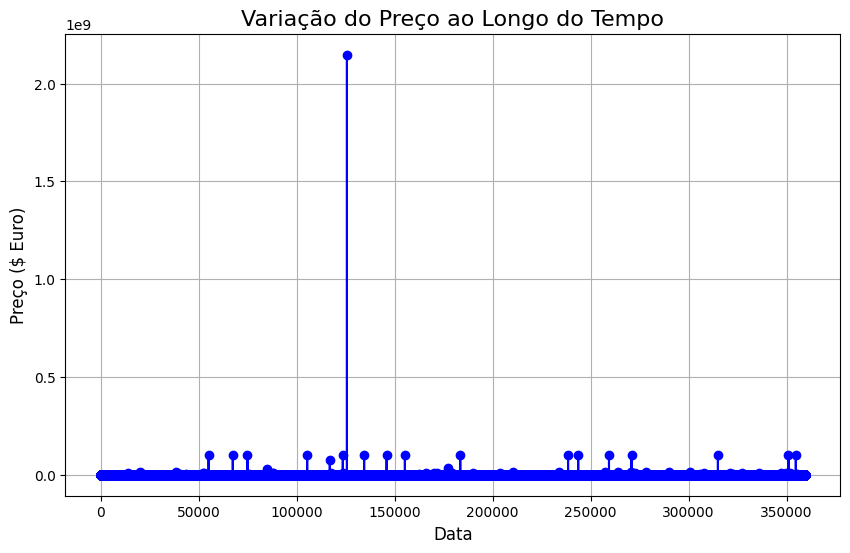

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

df = base.reset_index(drop=True)
# 2. Plotar o gráfico de linha
plt.figure(figsize=(10, 6)) # Define o tamanho da figura
plt.plot( df['price'], marker='o', linestyle='-', color='b')

# 3. Adicionar títulos e rótulos
plt.title('Variação do Preço ao Longo do Tempo', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço ($ Euro)', fontsize=12)
plt.grid(True) # Adiciona uma grade para facilitar a leitura
plt.show()

In [36]:
# outlier

i2 = base.loc[base.price > 350000]
i2.shape

(115, 12)

In [37]:
# retirar os outliers
base = base.loc[base.price < 350000]

In [38]:
base.shape

(359291, 12)

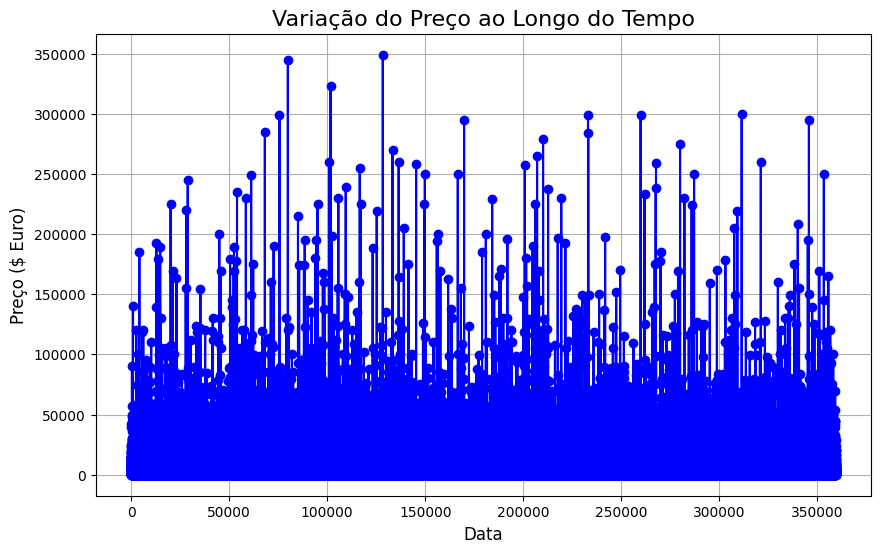

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

df = base.reset_index(drop=True)
# 2. Plotar o gráfico de linha
plt.figure(figsize=(10, 6)) # Define o tamanho da figura
plt.plot( df['price'], marker='o', linestyle='-', color='b')

# 3. Adicionar títulos e rótulos
plt.title('Variação do Preço ao Longo do Tempo', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço ($ Euro)', fontsize=12)
plt.grid(True) # Adiciona uma grade para facilitar a leitura
plt.show()

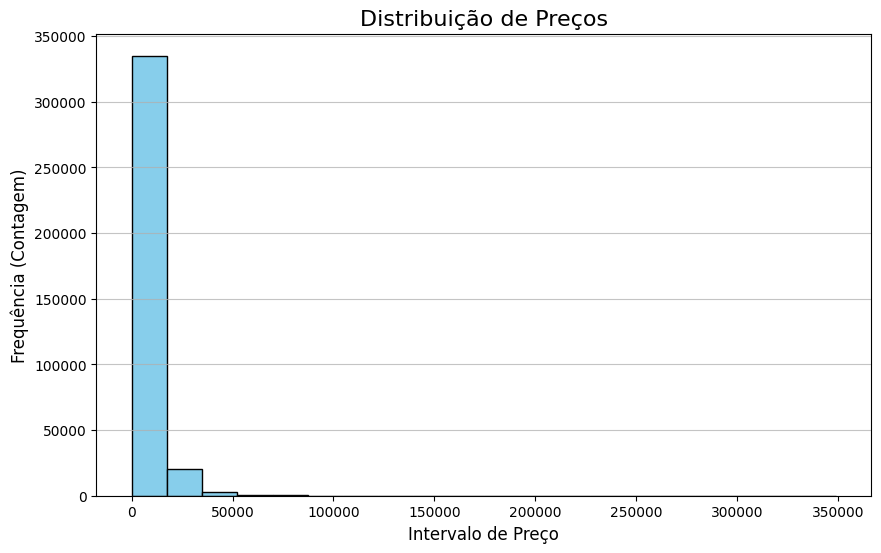

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparar os dados de exemplo
# Gerando 100 preços aleatórios para o exemplo
#prices = np.random.normal(loc=150, scale=20, size=500)

# 2. Plotar o histograma
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=20, color='skyblue', edgecolor='black')

# 3. Adicionar títulos e rótulos
plt.title('Distribuição de Preços', fontsize=16)
plt.xlabel('Intervalo de Preço', fontsize=12)
plt.ylabel('Frequência (Contagem)', fontsize=12)
plt.grid(axis='y', alpha=0.75) # Adiciona uma grade no eixo Y
plt.show()

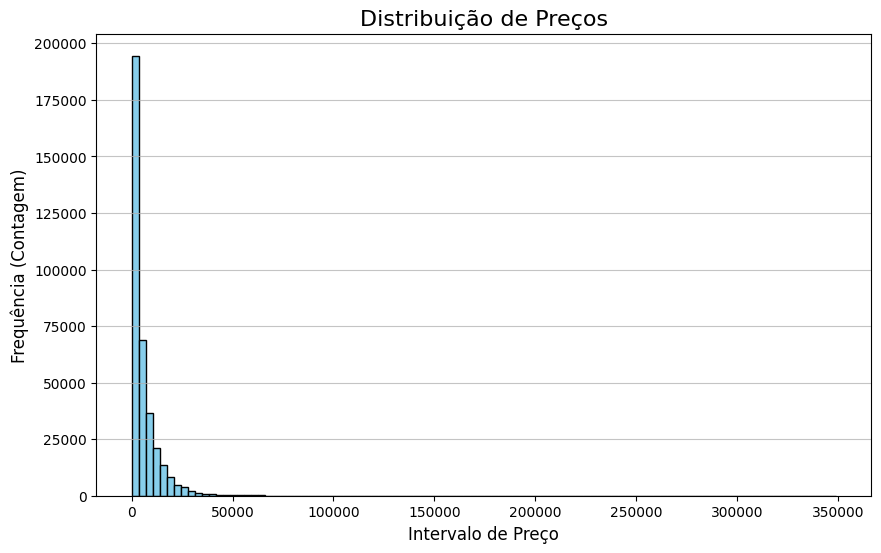

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparar os dados de exemplo
# Gerando 100 preços aleatórios para o exemplo
#prices = np.random.normal(loc=150, scale=20, size=500)

# 2. Plotar o histograma
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=100, color='skyblue', edgecolor='black')

# 3. Adicionar títulos e rótulos
plt.title('Distribuição de Preços', fontsize=16)
plt.xlabel('Intervalo de Preço', fontsize=12)
plt.ylabel('Frequência (Contagem)', fontsize=12)
plt.grid(axis='y', alpha=0.75) # Adiciona uma grade no eixo Y
plt.show()

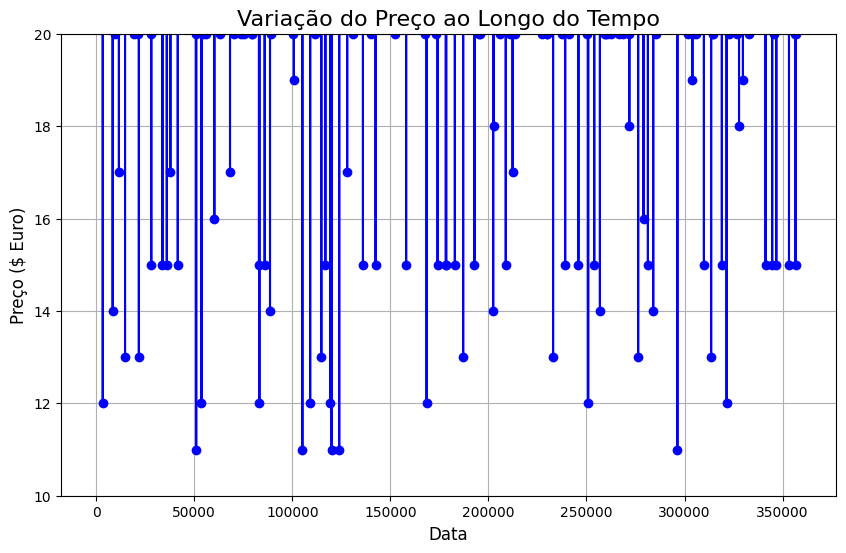

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


df = base.reset_index(drop=True)

# 2. Plotar o gráfico de linha
plt.figure(figsize=(10, 6)) # Define o tamanho da figura
plt.plot(df['price'], marker='o', linestyle='-', color='b')

# --- Adicionar esta linha para definir os limites do eixo Y ---
plt.ylim(10, 20)

# 3. Adicionar títulos e rótulos
plt.title('Variação do Preço ao Longo do Tempo', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço ($ Euro)', fontsize=12)
plt.grid(True) # Adiciona uma grade para facilitar a leitura
plt.show()

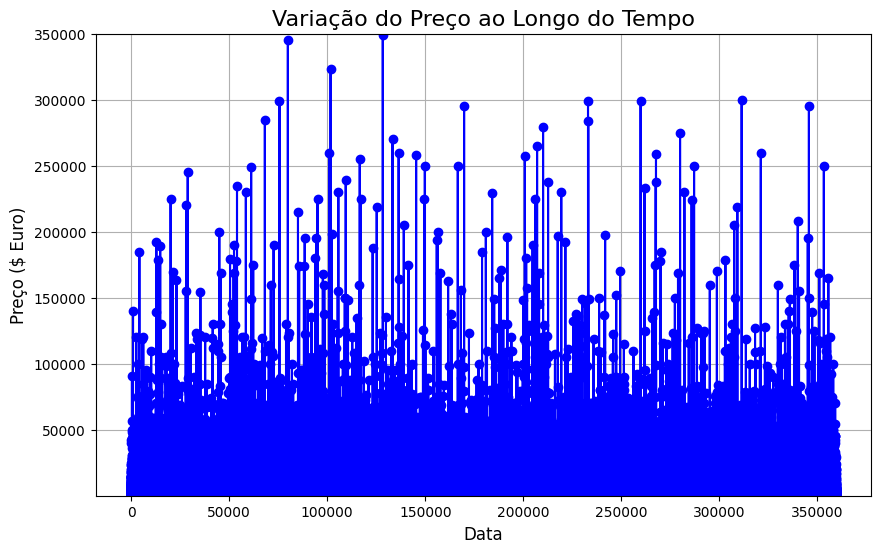

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# 2. Plotar o gráfico de linha
plt.figure(figsize=(10, 6)) # Define o tamanho da figura
plt.plot(df['price'], marker='o', linestyle='-', color='b')

# --- Adicionar esta linha para definir os limites do eixo Y ---
plt.ylim(10, 350000)

# 3. Adicionar títulos e rótulos
plt.title('Variação do Preço ao Longo do Tempo', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço ($ Euro)', fontsize=12)
plt.grid(True) # Adiciona uma grade para facilitar a leitura
plt.show()

## tratamentos dos valores nulos 

<Axes: >

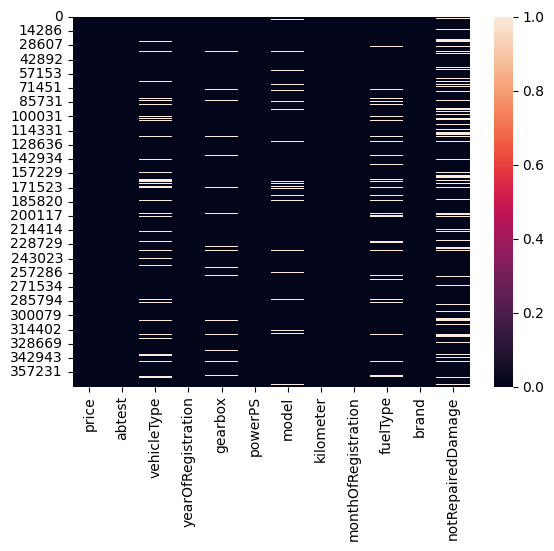

In [44]:
# verificar com o mapa de calores os dados nulos
sns.heatmap(base.isnull())

In [45]:
base.isnull().sum()

price                      0
abtest                     0
vehicleType            33546
yearOfRegistration         0
gearbox                17236
powerPS                    0
model                  17967
kilometer                  0
monthOfRegistration        0
fuelType               29391
brand                      0
notRepairedDamage      65986
dtype: int64

X atributos

y - valores dos registros

In [46]:
# valores nulos nas figuras estão em branco. Branco nulos nas posições. 

### O que tem mais valores nulos é a coluna 'notRepairedDamage'.

## Analisar o tipo do veículo 

##  vehicleType

In [47]:
base.loc[pd.isnull(base['vehicleType'])].tail(20) # verificar os valores nulos

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
371258,3600,test,NaN,2017,manuell,86,transit,150000,5,diesel,ford,NaN
371261,299,test,NaN,2016,manuell,60,astra,150000,4,benzin,opel,ja
371274,400,test,NaN,2000,NaN,0,twingo,150000,0,NaN,renault,NaN
371286,1000,control,NaN,2017,manuell,101,a4,150000,9,NaN,audi,NaN
371309,1500,control,NaN,1995,NaN,0,NaN,150000,0,NaN,volkswagen,NaN
371316,3000,control,NaN,2016,manuell,0,colt,150000,8,diesel,mitsubishi,nein
371349,1350,test,NaN,2016,manuell,0,clk,150000,8,NaN,mercedes_benz,ja
371354,2140,test,NaN,2018,manuell,80,fiesta,150000,6,NaN,ford,nein
371359,8700,test,NaN,2009,NaN,0,2_reihe,90000,8,benzin,peugeot,NaN
371370,790,test,NaN,1990,manuell,0,andere,150000,1,benzin,renault,NaN


In [48]:
len(base.loc[pd.isnull(base['vehicleType'])])

33546

In [49]:
base['vehicleType'].value_counts() # limousine é o veículo que mais aparece

vehicleType
limousine     93614
kleinwagen    78014
kombi         65921
bus           29699
cabrio        22509
coupe         18386
suv           14477
andere         3125
Name: count, dtype: int64

In [50]:
base['vehicleType'].unique()

array([nan, 'coupe', 'suv', 'kleinwagen', 'limousine', 'cabrio', 'bus',
       'kombi', 'andere'], dtype=object)

apagar o NaN ou substituir os valores da coluna vehicleType

## gearbox

In [51]:
len(base.loc[pd.isnull(base['gearbox'])])

17236

In [52]:
base.loc[pd.isnull(base['gearbox'])].tail()

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
371443,3300,control,kombi,2006,NaN,0,touran,150000,7,diesel,volkswagen,NaN
371460,3500,control,NaN,1995,NaN,0,polo,150000,0,NaN,volkswagen,NaN
371486,350,control,kleinwagen,1996,NaN,65,punto,150000,0,NaN,fiat,NaN
371495,180,control,NaN,1995,NaN,0,NaN,125000,3,benzin,opel,NaN
371523,2200,test,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN


In [53]:
base['gearbox'].unique()

array(['manuell', 'automatik', nan], dtype=object)

In [54]:
base['gearbox'].value_counts() # manuell 

gearbox
manuell      266547
automatik     75508
Name: count, dtype: int64

## model

In [55]:
len(base.loc[pd.isnull(base['model'])])

17967

In [56]:
base.loc[pd.isnull(base['model'])].tail(20)

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
371065,18500,test,limousine,2009,automatik,190,NaN,150000,10,diesel,audi,nein
371099,200,control,NaN,1910,NaN,0,NaN,5000,0,benzin,sonstige_autos,NaN
371102,1599,test,kleinwagen,2002,manuell,75,NaN,150000,0,benzin,ford,NaN
371110,1670,control,NaN,2018,manuell,0,NaN,90000,0,benzin,renault,nein
371121,1500,control,bus,1984,manuell,0,NaN,150000,5,diesel,mercedes_benz,NaN
371146,10980,test,NaN,2018,manuell,75,NaN,20000,1,NaN,volkswagen,nein
371150,1000,control,NaN,2017,manuell,54,NaN,125000,2,NaN,hyundai,nein
371196,42000,control,limousine,2012,automatik,564,NaN,50000,3,benzin,sonstige_autos,nein
371203,6000,test,kleinwagen,2008,manuell,155,NaN,150000,5,benzin,sonstige_autos,nein
371214,30900,control,cabrio,1960,automatik,250,NaN,100000,7,benzin,sonstige_autos,nein


In [57]:
base['model'].unique()

array(['golf', nan, 'grand', 'fabia', '3er', '2_reihe', 'c_max',
       '3_reihe', 'passat', 'navara', 'ka', 'polo', 'twingo', 'a_klasse',
       'scirocco', '5er', 'meriva', 'arosa', 'andere', 'c4', 'civic',
       'transporter', 'punto', 'e_klasse', 'clio', 'kadett', 'kangoo',
       'one', 'fortwo', '1er', 'b_klasse', 'signum', 'astra', 'a8',
       'jetta', 'fiesta', 'c_klasse', 'micra', 'vito', 'sprinter', '156',
       'escort', 'forester', 'xc_reihe', 'scenic', 'a4', 'a1', 'insignia',
       'combo', 'focus', 'tt', 'corsa', 'a6', 'jazz', 'omega', 'slk',
       '7er', '80', '147', 'glk', '100', 'z_reihe', 'sportage', 'sorento',
       'v40', 'ibiza', 'mustang', 'eos', 'touran', 'getz', 'a3', 'almera',
       'megane', 'lupo', 'r19', 'zafira', 'caddy', 'mondeo', 'cordoba',
       'colt', 'impreza', 'vectra', 'berlingo', 'm_klasse', 'tiguan',
       'i_reihe', 'espace', 'sharan', '6_reihe', 'panda', 'up',
       'seicento', 'ceed', '5_reihe', 'yeti', 'octavia', 'mii',
       'rx_re

In [58]:
base['model'].value_counts() # golf

model
golf               28989
andere             25560
3er                19905
polo               12604
corsa              12149
                   ...  
serie_2                8
rangerover             6
serie_3                3
serie_1                1
discovery_sport        1
Name: count, Length: 251, dtype: int64

## fuelType

In [59]:
len(base.loc[pd.isnull(base['fuelType'])])

29391

In [60]:
base.loc[pd.isnull(base['fuelType'])].tail()

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
371496,3850,test,cabrio,2006,manuell,108,2_reihe,125000,2,NaN,peugeot,nein
371504,2600,control,NaN,2005,automatik,0,c_klasse,150000,9,NaN,mercedes_benz,NaN
371509,1900,test,NaN,2000,manuell,110,NaN,150000,7,NaN,volkswagen,nein
371519,5250,control,NaN,2016,automatik,150,159,150000,12,NaN,alfa_romeo,nein
371523,2200,test,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN


In [61]:
base['fuelType'].value_counts() # benzin

fuelType
benzin     217582
diesel     106002
lpg          5222
cng           557
hybrid        271
andere        165
elektro       101
Name: count, dtype: int64

In [62]:
base['fuelType'].unique()

array(['benzin', 'diesel', nan, 'lpg', 'andere', 'hybrid', 'cng',
       'elektro'], dtype=object)

# último atributo  notRepairedDamage

In [63]:
base.loc[pd.isnull(base['notRepairedDamage'])].tail()

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
371507,5999,test,kombi,2005,manuell,140,a4,150000,4,diesel,audi,NaN
371514,999,control,cabrio,2000,manuell,95,megane,150000,4,benzin,renault,NaN
371515,1690,test,kombi,2004,manuell,55,fabia,150000,4,benzin,skoda,NaN
371523,2200,test,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN
371526,3400,test,kombi,2002,manuell,100,golf,150000,6,diesel,volkswagen,NaN


In [64]:
len(base.loc[pd.isnull(base['notRepairedDamage'])])

65986

In [65]:
base['notRepairedDamage'].value_counts() # nein

notRepairedDamage
nein    259301
ja       34004
Name: count, dtype: int64

nein => não

ja  => sim


In [66]:
base['notRepairedDamage'].unique()


array([nan, 'ja', 'nein'], dtype=object)

In [67]:
base.loc[pd.isnull(base['price'])]

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage


## Valores no formato do dicionário para preencher os dados nulos 

In [68]:
valores = {'vehicleType': 'limousine', 'gearbox': 'manuell',
           'model': 'golf', 'fuelType': 'benzin',
           'notRepairedDamage': 'nein'}
# colunas: valores que mais aparecem

In [69]:
base = base.fillna(value = valores)

In [70]:
base.tail()

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
371523,2200,test,limousine,2005,manuell,0,golf,20000,1,benzin,sonstige_autos,nein
371524,1199,test,cabrio,2000,automatik,101,fortwo,125000,3,benzin,smart,nein
371525,9200,test,bus,1996,manuell,102,transporter,150000,3,diesel,volkswagen,nein
371526,3400,test,kombi,2002,manuell,100,golf,150000,6,diesel,volkswagen,nein
371527,28990,control,limousine,2013,manuell,320,m_reihe,50000,8,benzin,bmw,nein


In [71]:
base.isnull().sum()

price                  0
abtest                 0
vehicleType            0
yearOfRegistration     0
gearbox                0
powerPS                0
model                  0
kilometer              0
monthOfRegistration    0
fuelType               0
brand                  0
notRepairedDamage      0
dtype: int64

In [72]:
# fazer testes
base.loc[pd.isnull(base['notRepairedDamage'])]

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage


## Terceiro tratamento dos dados 

# Pré processamento adicionais 

In [73]:
# 0 é o nosso objetivo preço

In [74]:
base.columns[1:13]

Index(['abtest', 'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS',
       'model', 'kilometer', 'monthOfRegistration', 'fuelType', 'brand',
       'notRepairedDamage'],
      dtype='object')

In [75]:
 base.columns[0]

'price'

In [76]:
base.shape

(359291, 12)

In [77]:
previsores = base.iloc[:, 1:13].values
preco_real = base.iloc[:, 0].values

In [78]:
previsores.shape

(359291, 11)

In [79]:
preco_real.shape

(359291,)

# Transformar os atributos categoricos em númericos 

## ideia para usar o OneHotEncoder

In [80]:
# temos que ter cuidado para o tipo

# fazer a representação única
# gol  1 0 0
# pali 0 1 0
# uno  0 0 1
      

In [81]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
# 0 0 0
# 0 1 0
# 0 0 1

In [82]:
atributos = base.iloc[:, 1:13].tail(2).reset_index(drop=True)
atributos

,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
0,test,kombi,2002,manuell,100,golf,150000,6,diesel,volkswagen,nein
1,control,limousine,2013,manuell,320,m_reihe,50000,8,benzin,bmw,nein


In [83]:
len(list(atributos.columns))

11

In [84]:
print(list(atributos.columns))


['abtest', 'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model', 'kilometer', 'monthOfRegistration', 'fuelType', 'brand', 'notRepairedDamage']


In [85]:
# Encontra a posição (índice) da coluna 'price'

for col in list(atributos.columns):

   posicao_col = df.columns.get_loc(f'{col}')
    
   print(f"O índice da coluna {col} é: {posicao_col-1}")

O índice da coluna abtest é: 0
O índice da coluna vehicleType é: 1
O índice da coluna yearOfRegistration é: 2
O índice da coluna gearbox é: 3
O índice da coluna powerPS é: 4
O índice da coluna model é: 5
O índice da coluna kilometer é: 6
O índice da coluna monthOfRegistration é: 7
O índice da coluna fuelType é: 8
O índice da coluna brand é: 9
O índice da coluna notRepairedDamage é: 10


In [86]:
# transformer em forma de lista

onehotencoder = ColumnTransformer(transformers = [("OneHot", OneHotEncoder(), # encoder para fazer as transformações
                                                   [0,1,3,5,8,9,10])], # índices dos atributos que queremos transformar. Número das colunas
                                  remainder = 'passthrough') 
 # remainder = 'passthrough' =>passar pelas colunas restantes, e vai 
#se não tiver o padrão é drop e as colunas  [0,1,3,5,8,9,10] serão apagadas



In [87]:
# para colocar no formato encoder único e no formato array
previsores = onehotencoder.fit_transform(previsores).toarray()

In [88]:
previsores

array([[0.00e+00, 1.00e+00, 0.00e+00, ..., 0.00e+00, 1.50e+05, 0.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, ..., 1.90e+02, 1.25e+05, 5.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, ..., 1.63e+02, 1.25e+05, 8.00e+00],
       ...,
       [0.00e+00, 1.00e+00, 0.00e+00, ..., 1.02e+02, 1.50e+05, 3.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, ..., 1.00e+02, 1.50e+05, 6.00e+00],
       [1.00e+00, 0.00e+00, 0.00e+00, ..., 3.20e+02, 5.00e+04, 8.00e+00]])

In [89]:
previsores.shape

(359291, 316)

In [90]:
# se tivermos 100 tipos de carros será criado no onehotencoder mais 100 novas colunas.

In [91]:
previsores[0] #posicionamentos do primeiro registro

array([0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 

In [92]:
type(previsores)

numpy.ndarray

In [93]:
previsores = torch.tensor(previsores, dtype = torch.float)
preco_real = torch.tensor(preco_real, dtype = torch.float).view(-1, 1) # como um reshape para definir a posição

In [94]:
type(previsores)

torch.Tensor

In [95]:
preco_real.shape # formato de matriz

torch.Size([359291, 1])

## Etapa 3: Construção do modelo

Modelo da rede neural


In [96]:
previsores.shape

torch.Size([359291, 316])

In [97]:
print(f'São {previsores.shape[1]} colunas ou variáveis (features) de previsão para colocar como neurônios na camada de entrada (input)')

São 316 colunas ou variáveis (features) de previsão para colocar como neurônios na camada de entrada (input)


In [98]:
# 316 depois do onehotencoder

In [99]:
(316 + 1) / 2

158.5

In [100]:
# 316 -> 158 -> 158 -> 1 (camada de saída)
# (entradas + saídas) / 2 = (316 + 1) / 2
regressor = nn.Sequential(nn.Linear(316, 158),
                          nn.ReLU(), # ReLu de ativação
                          nn.Linear(158, 158),
                          nn.ReLU(), # ReLu de ativação 
                          nn.Linear(158, 1)) # como é regressão, não precisamos trazer a função de ativação.

In [101]:
# ReLU dados negativos zera, caso contrário passa o valor real.

In [102]:
regressor

Sequential(
  (0): Linear(in_features=316, out_features=158, bias=True)
  (1): ReLU()
  (2): Linear(in_features=158, out_features=158, bias=True)
  (3): ReLU()
  (4): Linear(in_features=158, out_features=1, bias=True)
)

#### L1Loss =>  função de perda que mede a diferença entre a previsão do seu modelo e o valor real. O objetivo do treinamento de qualquer modelo de machine learning é minimizar essa perda.



A L1Loss é também conhecida como Erro Absoluto Médio (MAE). Ela funciona calculando a diferença absoluta entre cada valor previsto e cada valor verdadeiro, e em seguida, tirando a média dessas diferenças.

Exemplo:

Valor Real: 10

Previsão do Modelo: 8

_Cálculo da Perda L1: ∣10−8∣=2_

Se você tiver várias previsões, ele simplesmente fará a média de todos esses erros absolutos.

**Vantagens do L1Loss**

A L1Loss é usada principalmente em problemas de regressão, onde o modelo prevê um valor numérico contínuo (como o preço de uma casa, a temperatura ou a altura de uma pessoa), e não em problemas de classificação.

Uma das grandes vantagens da L1Loss é que ela é mais robusta a outliers do que a MSELoss (Erro Quadrático Médio), que penaliza erros grandes de forma muito mais severa (pois eleva a diferença ao quadrado). Se seu conjunto de dados tem alguns valores extremos, a L1Loss pode ser uma escolha mais segura.

In [103]:
criterion = nn.L1Loss()  # criterion é função do erro. Que vale como mean error

In [104]:
criterion

L1Loss()

Configurando o Otimizador

A linha optimizer = optim.Adam(regressor.parameters()) configura o otimizador, que é o motor do processo de aprendizado. Ele tem a função de ajustar os pesos e vieses do nosso modelo (regressor) a cada passo do treinamento para minimizar o erro.

optim.Adam: <b>Adam</b> é um dos algoritmos de otimização mais populares e eficazes. Ele <b>ajusta a taxa de aprendizado</b> de forma automática para cada parâmetro, tornando o processo de treinamento mais rápido e eficiente.

regressor.parameters(): Esta parte informa ao otimizador quais parâmetros ele deve otimizar. Ele aponta para todos os pesos e vieses que compõem o modelo do seu regressor.



In [105]:
optimizer = optim.Adam(regressor.parameters()) # com os valores default 

In [106]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

In [107]:
dataset = torch.utils.data.TensorDataset(previsores, preco_real)
train_loader = torch.utils.data.DataLoader(dataset, batch_size=300, shuffle=True) # shuffle ára misturar os dados

Combina os dados dos previsores (características) e do preco_real (valor alvo) para um único objeto TensorDataset.

Carregador de dados (DataLoader): 

Agrupar seus dados em lotes (neste caso, com batch_size=300). Isso é crucial para o treinamento, pois o modelo aprende processando mini-lotes, o que é mais estável e economiza memória.

Embaralhar (shuffle=True) os dados a cada época. Isso evita que o modelo aprenda a ordem dos dados, o que poderia prejudicar sua capacidade de generalizar para novas informações.


# tipo de cpu

## Etapa 4: Treinamento do modelo

In [108]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

no colab jupyter => edit - notebook settings GPU cuda

In [110]:
regressor.to(device) # o processo vai para o cpu ou cuda e mostra a arquitura da estrutura neural. 

Sequential(
  (0): Linear(in_features=316, out_features=158, bias=True)
  (1): ReLU()
  (2): Linear(in_features=158, out_features=158, bias=True)
  (3): ReLU()
  (4): Linear(in_features=158, out_features=1, bias=True)
)

Suponha que tenhamos 10.000 exemplos de treino.

decidimos usar mini-batches de 100 exemplos.

Isso significa que, para completar 1 época, serão feitos:

10.000/100  = 100 atualizações (batches)

Se treinar por 10 épocas, cada exemplo do conjunto de treino será visto 10 vezes pelo modelo.

---------------------

Se treinar por poucas épocas, o modelo pode não aprender bem (subajuste).

Se treinar por muitas épocas, o modelo pode decorar os dados de treino (sobreajuste/overfitting).


Época = 1 volta completa pelos dados de treino.

Durante várias épocas, a rede ajusta os pesos até encontrar um bom equilíbrio entre aprender os padrões e não decorar demais os dados.


In [ ]:
for epoch in range(100):
  running_loss = 0.  # calculo da perda
  running_mae = 0.  # calculo do erro mae

  # train_loader contém dados em byte https://docs.pytorch.org/docs/stable/generated/torch.Tensor.byte.html
  for i, data in enumerate(train_loader):
    #inputs é o previstor, com as variáveis e labels é o dado real dos preços
    inputs, labels = data
    # colocar na cpu no processo
    inputs, labels = inputs.to(device), labels.to(device)
    # zerar os gradientes quando passar em cada for. 
    optimizer.zero_grad()
    # passar os processos para frente. 
    # tendo o outputs, que é a previsão, temos os erros.
    outputs = regressor.forward(inputs)
    # Erro Absoluto Médio (MAE)
    #Soma-se todos esses erros absolutos e divide-se pelo número total de pontos de dados
    mae = F.l1_loss(outputs, labels).item()
    # ll_loss para calcular os erros, valores dos erros. 
    # calcular o absoluto mae
    running_mae += mae
    # otimizador, com o erro no treinamento
    loss = criterion(outputs, labels)
    # voltar a estrutura da rede neural e atualizar os pesos
    loss.backward()
    # atualizar os pesos
    optimizer.step()

    running_loss += loss.item()
    #3d para comparar
    # // divisão para não pegar valores com ,
    print('\rÉpoca {:3d} - Loop {:3d} de {:3d}: perda {:06.2f} - MAE {:06.2f}'.format(epoch+1,
                                                                                      i + 1,
                                                                                      len(preco_real)//300, 
                                                                                      loss, mae))
  print('ÉPOCA {:3d} finalizada: perda {:0.5f} - MAE {:0.5f} '.format(epoch+1,
                                                                      running_loss/len(train_loader),
                                                                      running_mae/len(train_loader)))

Época   1 - Loop   1 de 1197: perda 6136.03 - MAE 6136.03
Época   1 - Loop   2 de 1197: perda 5353.35 - MAE 5353.35
Época   1 - Loop   3 de 1197: perda 4496.61 - MAE 4496.61
Época   1 - Loop   4 de 1197: perda 5171.38 - MAE 5171.38
Época   1 - Loop   5 de 1197: perda 5409.99 - MAE 5409.99
Época   1 - Loop   6 de 1197: perda 6065.02 - MAE 6065.02
Época   1 - Loop   7 de 1197: perda 4835.86 - MAE 4835.86
Época   1 - Loop   8 de 1197: perda 4532.98 - MAE 4532.98
Época   1 - Loop   9 de 1197: perda 5370.05 - MAE 5370.05
Época   1 - Loop  10 de 1197: perda 4782.45 - MAE 4782.45
Época   1 - Loop  11 de 1197: perda 4826.18 - MAE 4826.18
Época   1 - Loop  12 de 1197: perda 5251.10 - MAE 5251.10
Época   1 - Loop  13 de 1197: perda 5697.10 - MAE 5697.10
Época   1 - Loop  14 de 1197: perda 5104.04 - MAE 5104.04
Época   1 - Loop  15 de 1197: perda 4780.18 - MAE 4780.18
Época   1 - Loop  16 de 1197: perda 5019.60 - MAE 5019.60
Época   1 - Loop  17 de 1197: perda 4820.53 - MAE 4820.53
Época   1 - Lo